# <p style='color: red; text-align: center'>Devoir</p>


## <p style='color: #87CEEB;'>1. Enoncé</p>

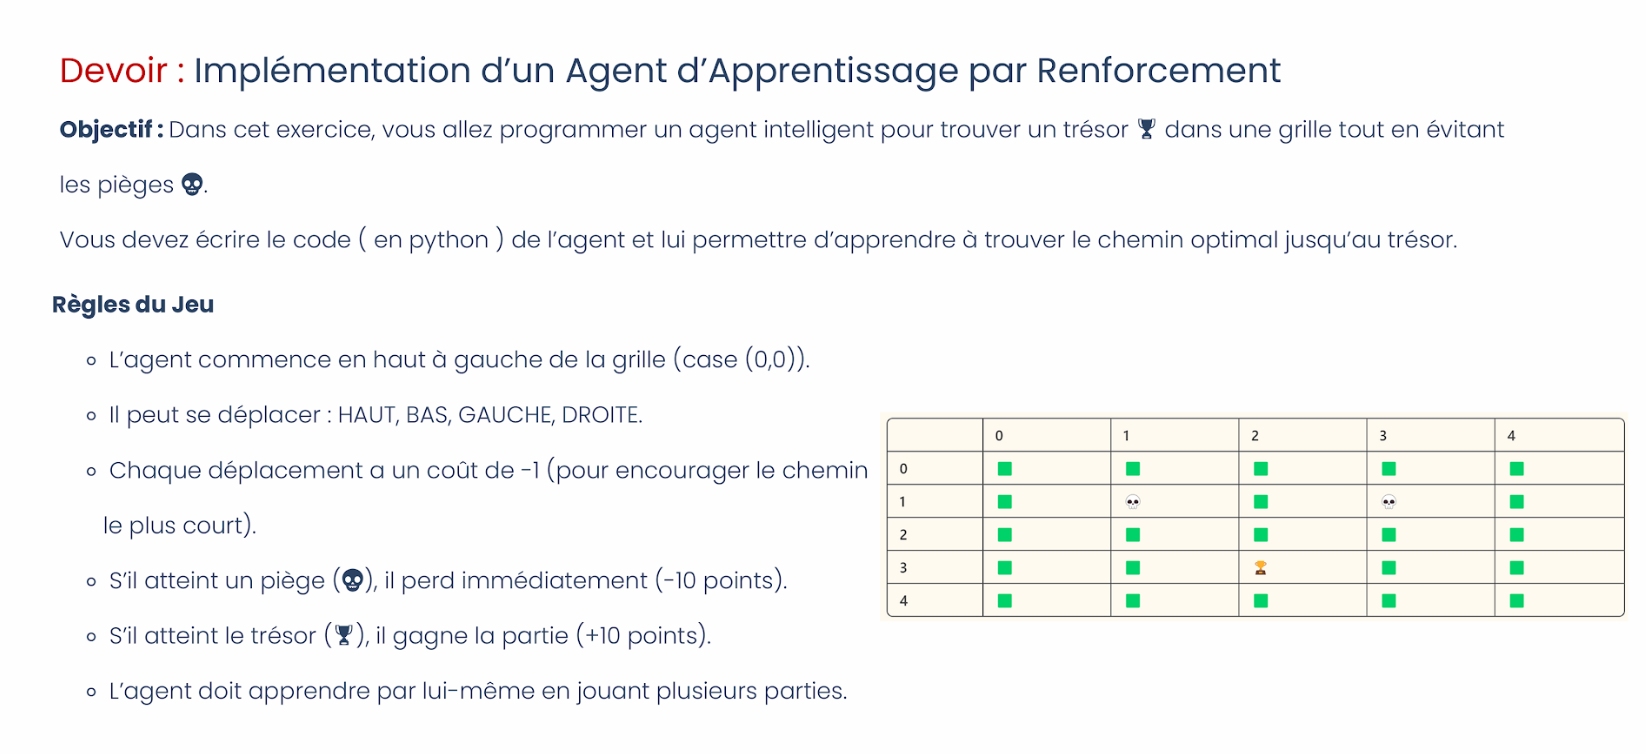

## <p style='color: #87CEEB;'>2. Solution</p>

In [18]:
import time
import random
from IPython.display import clear_output

# Paramètres de la grille
grid_size = 5
start = (0, 0)
treasure = (4, 4)
traps = [(1, 3), (2, 2), (3, 1)]

def display_grid_notebook(agent_pos, attempt):
    """
    Efface la sortie du notebook et affiche la grille avec :
      - 'A' pour l’agent
      - '🏆' pour le trésor
      - '💀' pour les pièges
      - '.' pour les cases vides
    """
    clear_output(wait=True)
    print(f"Tentative n°{attempt}\n")
    for i in range(grid_size):
        row_str = ''
        for j in range(grid_size):
            if (i, j) == agent_pos:
                row_str += ' A '
            elif (i, j) == treasure:
                row_str += ' 🏆 '
            elif (i, j) in traps:
                row_str += ' 💀 '
            else:
                row_str += ' . '
        print(row_str)
    print()

def random_step(state):
    """
    Effectue un déplacement aléatoire parmi Haut, Bas, Gauche, Droite.
    Renvoie (nouvel état, done) :
      - done est True si l’agent atteint le trésor ou tombe dans un piège.
    """
    i, j = state
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    di, dj = random.choice(moves)
    new_i, new_j = i + di, j + dj

    # Vérifie qu'on reste dans la grille
    if 0 <= new_i < grid_size and 0 <= new_j < grid_size:
        new_state = (new_i, new_j)
    else:
        new_state = state

    # Vérifie si on a atteint un piège ou le trésor
    done = (new_state in traps) or (new_state == treasure)
    return new_state, done

def play_random_episode(attempt):
    """
    Exécute une tentative où l'agent se déplace aléatoirement.
    L'épisode s'arrête si l'agent tombe dans un piège ou trouve le trésor.
    Renvoie True si le trésor a été trouvé, False sinon.
    """
    state = start
    done = False

    while not done:
        display_grid_notebook(state, attempt)
        time.sleep(0.5)  # Pause pour l'animation
        state, done = random_step(state)

    # Affichage final de l'état
    display_grid_notebook(state, attempt)
    if state == treasure:
        print("🏁 L'agent a trouvé le trésor !")
        return True
    elif state in traps:
        print("💀 L'agent est tombé dans un piège.")
        return False
    else:
        print("🛑 L'agent s'est arrêté.")
        return False

def simulate_multiple_episodes(max_attempts=10):
    """
    Lance des épisodes successifs jusqu'à ce que l'agent trouve le trésor
    ou que le nombre maximum de tentatives soit atteint.
    """
    for attempt in range(1, max_attempts + 1):
        result = play_random_episode(attempt)
        if result:
            print(f"\nLe trésor a été trouvé en {attempt} tentative(s) !")
            return
        else:
            print(f"\nTentative {attempt} échouée, on réessaye...\n")
            time.sleep(1)
    print("Nombre maximum de tentatives atteint. Le trésor n'a pas été trouvé.")

# Exécution dans un notebook
simulate_multiple_episodes()


Tentative n°10

 .  .  .  .  . 
 .  .  .  💀  . 
 .  .  A  .  . 
 .  💀  .  .  . 
 .  .  .  .  🏆 

💀 L'agent est tombé dans un piège.

Tentative 10 échouée, on réessaye...

Nombre maximum de tentatives atteint. Le trésor n'a pas été trouvé.
